t: 0.002 [s], Average temperature: 28.89 Celcius


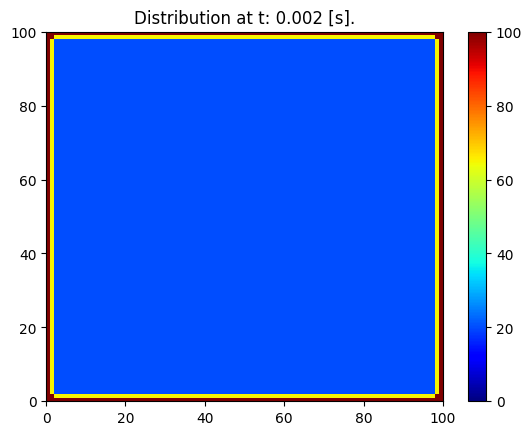

t: 0.005 [s], Average temperature: 30.21 Celcius
t: 0.007 [s], Average temperature: 31.30 Celcius
t: 0.009 [s], Average temperature: 32.25 Celcius
t: 0.012 [s], Average temperature: 33.10 Celcius
t: 0.014 [s], Average temperature: 33.88 Celcius
t: 0.016 [s], Average temperature: 34.61 Celcius
t: 0.019 [s], Average temperature: 35.29 Celcius
t: 0.021 [s], Average temperature: 35.92 Celcius
t: 0.023 [s], Average temperature: 36.53 Celcius
t: 0.026 [s], Average temperature: 37.10 Celcius
t: 0.028 [s], Average temperature: 37.66 Celcius
t: 0.030 [s], Average temperature: 38.19 Celcius
t: 0.032 [s], Average temperature: 38.70 Celcius
t: 0.035 [s], Average temperature: 39.19 Celcius
t: 0.037 [s], Average temperature: 39.66 Celcius
t: 0.039 [s], Average temperature: 40.12 Celcius
t: 0.042 [s], Average temperature: 40.57 Celcius
t: 0.044 [s], Average temperature: 41.01 Celcius
t: 0.046 [s], Average temperature: 41.43 Celcius
t: 0.049 [s], Average temperature: 41.84 Celcius
t: 0.051 [s], Averag

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# Defining our problem

a = 127
length = 100 #mm
time = 4 #seconds
nodes = 100

# Initialization 

dx = length / (nodes-1)
dy = length / (nodes-1)

dt = min(   dx**2 / (4 * a),     dy**2 / (4 * a))

t_nodes = int(time/dt) + 1

u = np.zeros((nodes, nodes)) + 15 # Plate is initially as 15 degres C

# Boundary Conditions 

u[0, :] = 200
u[-1, :] = 200

u[:, 0] = 200
u[:, -1] = 200

# Visualizing with a plot

fig, axis = plt.subplots()

pcm = axis.pcolormesh(u, cmap=plt.cm.jet, vmin=0, vmax=100)
plt.colorbar(pcm, ax=axis)

# Simulating

counter = 0

while u[50, 50] <= 60 :

    w = u.copy()

    for i in range(1, nodes - 1):
        for j in range(1, nodes - 1):

            dd_ux = (w[i-1, j] - 2*w[i, j] + w[i+1, j])/dx**2
            dd_uy = (w[i, j-1] - 2*w[i, j] + w[i, j+1])/dy**2

            u[i, j] = dt * a * (dd_ux + dd_uy) + w[i, j]

    counter += dt

    print(f"midtpunktet er {u[50, 50]:.3f} [C] ved {counter:.3f}[s]")

    # Updating the plot

    pcm.set_array(u)
    axis.set_title("Distribution at t: {:.3f} [s].".format(counter))
    plt.pause(0.01)


plt.show()